# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

# Análisis Descriptivo

In [110]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### La presente investigación busca estudiar la relación que existe entre el peso y los caballos de fuerza de un vehículo usando la base de datos de sns "mpg", la cual contiene un registro de las características de diferentes modelos de auto.

### Como es bien sabido los caballos de fuerza son una expresión de la potencia del motor. Sin embargo esta puede verse alterada por el peso de los materiales de construcción, accesorios, cableado, etc. Se propone buscar una relación lineal entre el peso y los caballos de fuerza.

In [111]:
# Se visualiza el dataset.
sns.load_dataset('mpg')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [112]:
# Importar dataset

df_car = sns.load_dataset('mpg')
df_car.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [113]:
# Análisis descriptivo

df_car.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [114]:
# Información de las variables del dataset

df_car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [125]:
# Definimos alias para las columnas de interés.

hp = df_car['horsepower']
weight = df_car['weight']
cylinders = df_car['cylinders']

print(len(hp),len(weight), len(cylinders))

392 392 392


## Análisis Univariable

### A continuación se crea la función "print_stats" que realiza una descripción estadística general de cada columna que se quiera analizar, además de realizar gráficas de interés.

In [126]:
# Descripción estadística general

def print_stats(data):

    name = data.name
    media = data.mean()
    mediana = data.median()
    desviacion_estandar = data.std()
    varianza = data.var()

    print(f'\nEstadísticas Generales {data.name}\n')
    print(f'Media: {data.mean():.3f}')
    print(f'Mediana: {data.median():.3f}')
    print(f'Desviación estándar: {data.std():.3f}')
    print(f'Varianza: {data.var():.3f}')
    print(f'Moda: {data.mode()[0]:.3f}')
    print(f'Mínimo: {data.min():.3f}')
    print(f'Máximo: {data.max():.3f}')
    print('\n')


    # Graficación #
    '''
    plt.scatter(range(len(data)), data, label = data.name, s = 6)
    plt.axhline(data.mean(), linestyle = '--', label = 'media')
    plt.axhline(data.mean()+hp.std(), linestyle = '--', color ='red', label = 'media +/- std')
    plt.axhline(data.mean()-hp.std(), linestyle = '--', color ='red')
    plt.legend()
    plt.show()
    '''

    # Percentiles #
    print(f'\nPercentiles {data.name}\n')
    print(f'Percentil 75: {data.quantile(0.75):.3f}')
    print(f'Percentil 25: {data.quantile(0.25):.3f}')
    print(f'Percentil 50: {data.quantile(0.50):.3f}')
    print(f'\n')

    p25 = data.quantile(0.25)
    p50 = data.quantile(0.50)
    p75 = data.quantile(0.75)

    # Graficacion Histograma #
    '''
    plt.figure(figsize=(8, 4))
    sns.histplot(data.dropna(), kde=True)
    plt.axvline(data.mean(), color='red', linestyle='dashed', linewidth=1, label='Promedio')
    plt.axvline(data.median(), color='green', linestyle='dashed', linewidth=1, label='Mediana')
    plt.legend()
    plt.title(f'Distribución de {name}')
    plt.xlabel(f'{name}')
    plt.ylabel('Frecuencia')
    plt.show()
    '''

    # Graficación Final #

    fig, ax = plt.subplots(3, figsize=(10,16), gridspec_kw = {'hspace':0.5})

    #sns.boxplot(data.dropna(), ax=ax[0], vert = False)
    ax[0].boxplot(data.dropna())
    #ax[0].axhline(p25, color = 'blue', linestyle = '--')
    #ax[0].axhline(p50, color = 'green', linestyle = '--')
    #ax[0].axhline(p75, color = 'red', linestyle = '--')
    ax[0].set_title(f'Boxplot de {name}')
    ax[0].set_ylabel(f'{name}')
    #ax[0].boxplot(data, labels = [name])

    ax[1].scatter(range(len(data)), data, label = data.name, s = 6)
    ax[1].axhline(data.mean(), linestyle = '--', label = 'media')
    ax[1].axhline(data.mean()+hp.std(), linestyle = '--', color ='red', label = 'media +/- std')
    ax[1].axhline(data.mean()-hp.std(), linestyle = '--', color ='red')
    ax[1].legend()
    ax[1].set_title('Scatterplot')

    ax[2].hist(data.dropna(), bins = 20, alpha = 0.7, density = True, edgecolor='black', linewidth = 1.2)
    sns.kdeplot(data.dropna(), ax=ax[2], color='black', linestyle='-', label='Densidad (KDE)')
    ax[2].axvline(data.mean(), color='red', linestyle='dashed', linewidth=1, label='Promedio')
    ax[2].axvline(data.median(), color='green', linestyle='dashed', linewidth=1, label='Mediana')
    ax[2].legend()
    ax[2].set_title(f'Distribución de {name}')
    ax[2].set_xlabel(f'{name}')
    ax[2].set_ylabel('Frecuencia')

    plt.show()

    return #media, desviacion_estandar


Estadísticas Generales horsepower

Media: 104.469
Mediana: 93.500
Desviación estándar: 38.491
Varianza: 1481.569
Moda: 150.000
Mínimo: 46.000
Máximo: 230.000



Percentiles horsepower

Percentil 75: 126.000
Percentil 25: 75.000
Percentil 50: 93.500




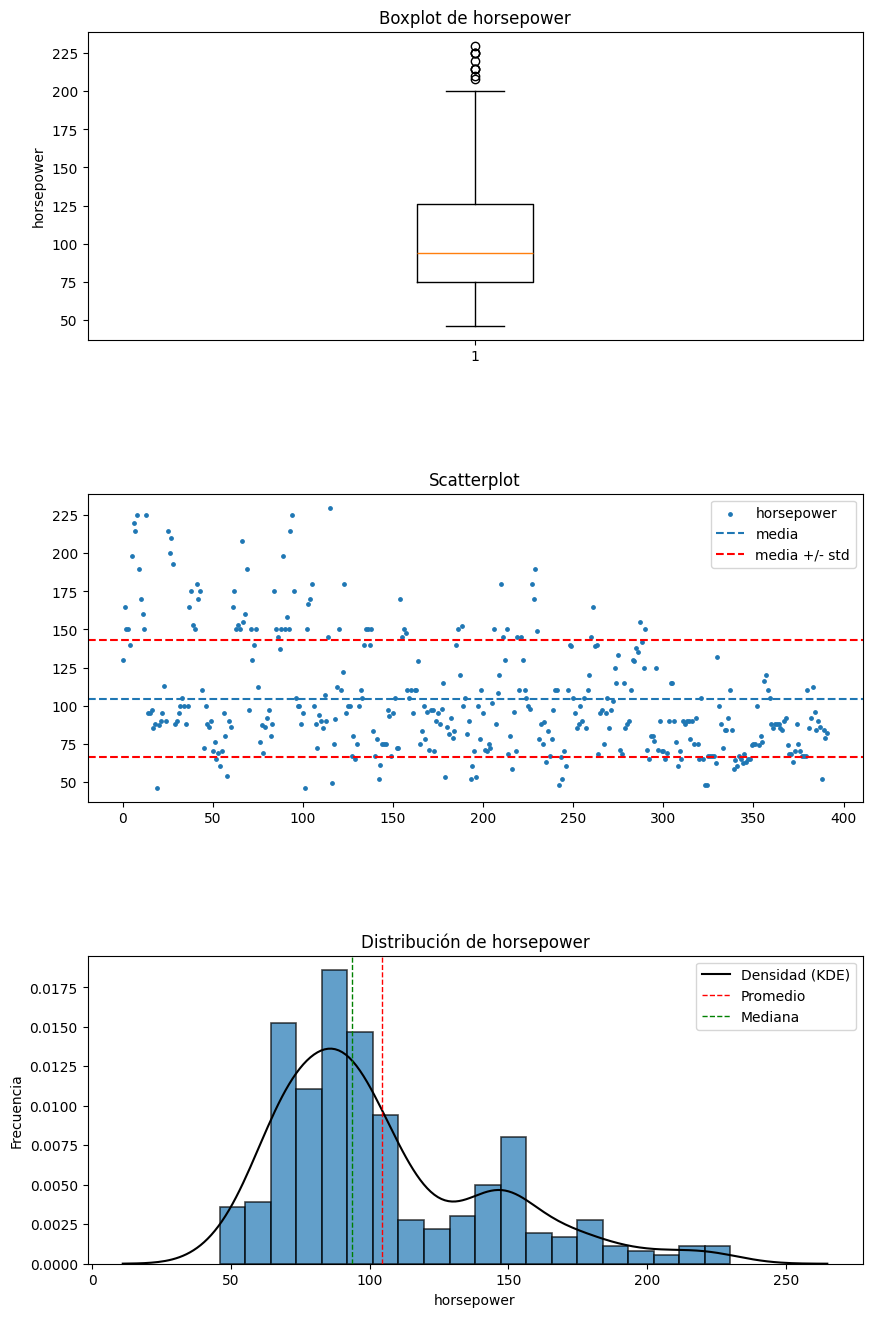

In [127]:
print_stats(hp)


Estadísticas Generales weight

Media: 2977.584
Mediana: 2803.500
Desviación estándar: 849.403
Varianza: 721484.709
Moda: 1985.000
Mínimo: 1613.000
Máximo: 5140.000



Percentiles weight

Percentil 75: 3614.750
Percentil 25: 2225.250
Percentil 50: 2803.500




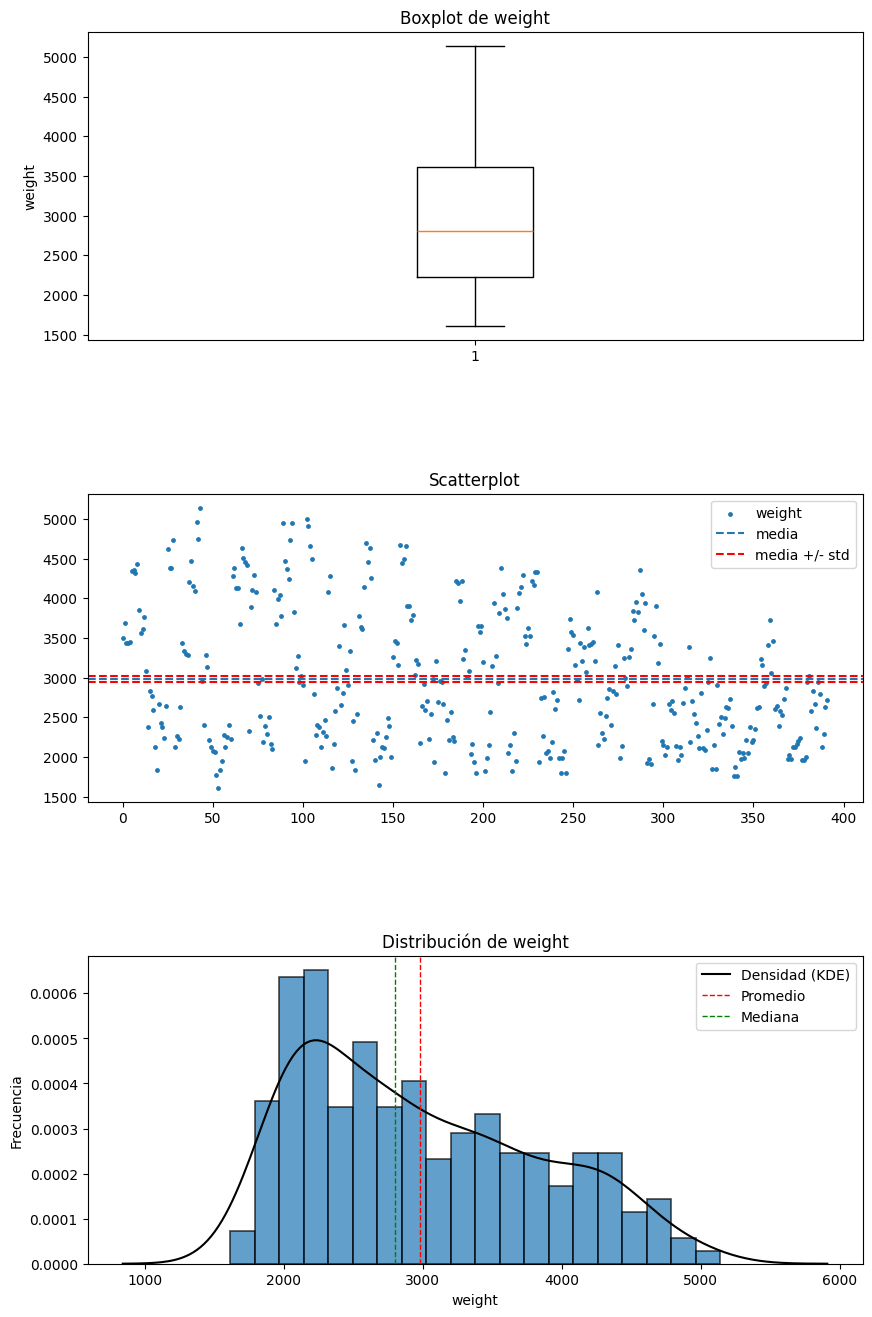

In [128]:
print_stats(weight)


Estadísticas Generales cylinders

Media: 5.472
Mediana: 4.000
Desviación estándar: 1.706
Varianza: 2.910
Moda: 4.000
Mínimo: 3.000
Máximo: 8.000



Percentiles cylinders

Percentil 75: 8.000
Percentil 25: 4.000
Percentil 50: 4.000




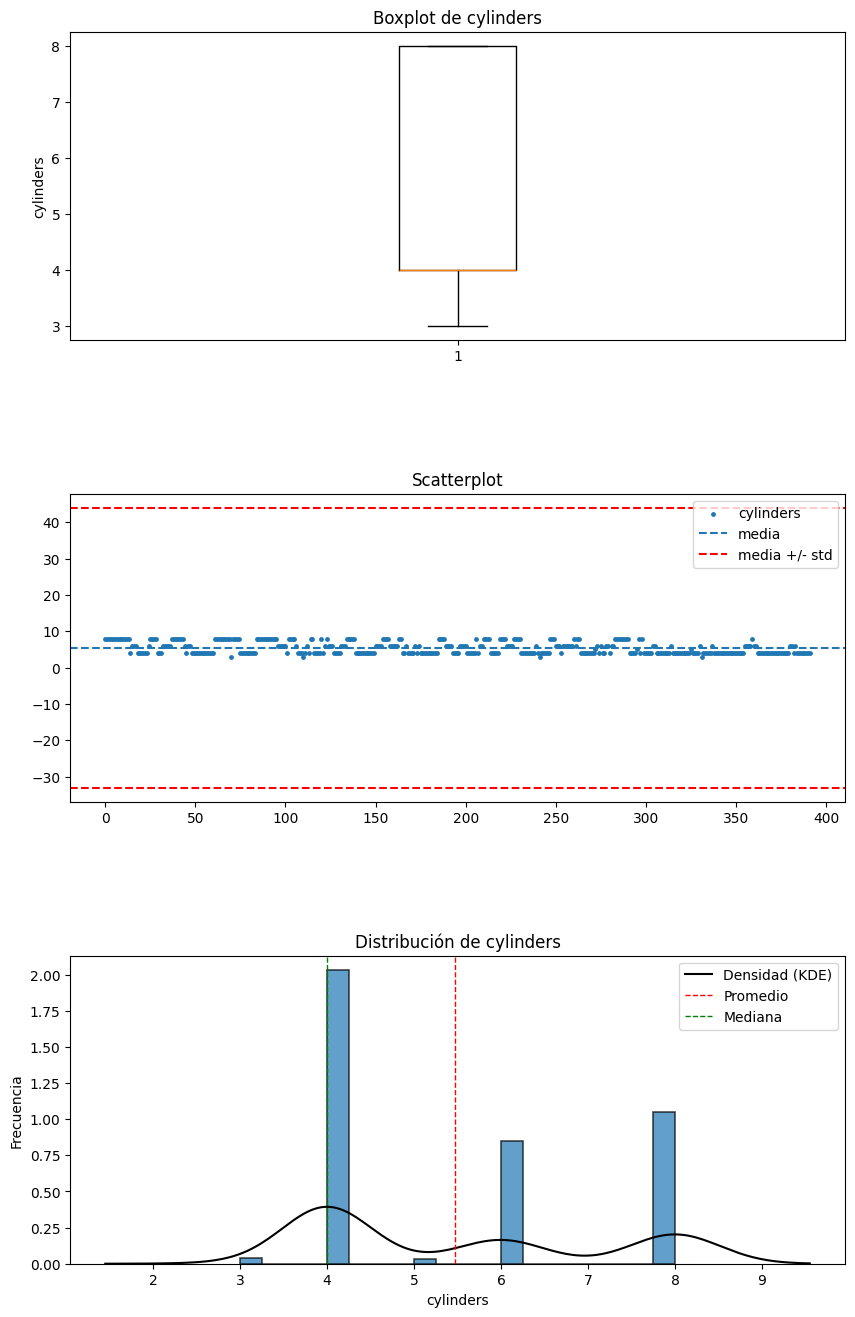

In [129]:
print_stats(df_car['cylinders'])

## Análisis Bivariable

### Se sabe que los caballos de fuerza dependen directamente de los cilindros que tenga el motor, pues en ellos recae la potencia de este. Por esto se agrega al análisis de correlación.

,horsepower,weight,cylinders
horsepower,1.000000,0.864538,0.842983
weight,0.864538,1.000000,0.897527
cylinders,0.842983,0.897527,1.000000


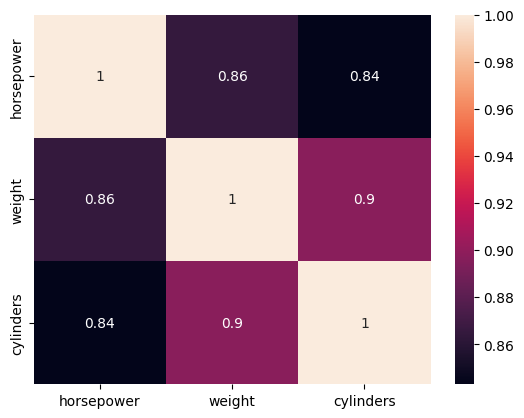

In [130]:
# Heatmap

columnas = ['horsepower', 'weight','cylinders']
corr = df_car[columnas].corr()
sns.heatmap(corr, annot=True)
corr

### A continuación se muestra la correlación lineal que tienen las columnas de interés (peso, caballos de fuerza y numero de cilindros).

In [131]:
corr_hp_weight = round(df_car['horsepower'].corr(df_car['weight']),3)
corr_hp_cylinders = round(df_car['horsepower'].corr(df_car['cylinders']),3)
corr_weight_cylinders = round(df_car['weight'].corr(df_car['cylinders']),3)

print(corr_hp_weight,corr_hp_cylinders,corr_weight_cylinders)

0.865 0.843 0.898


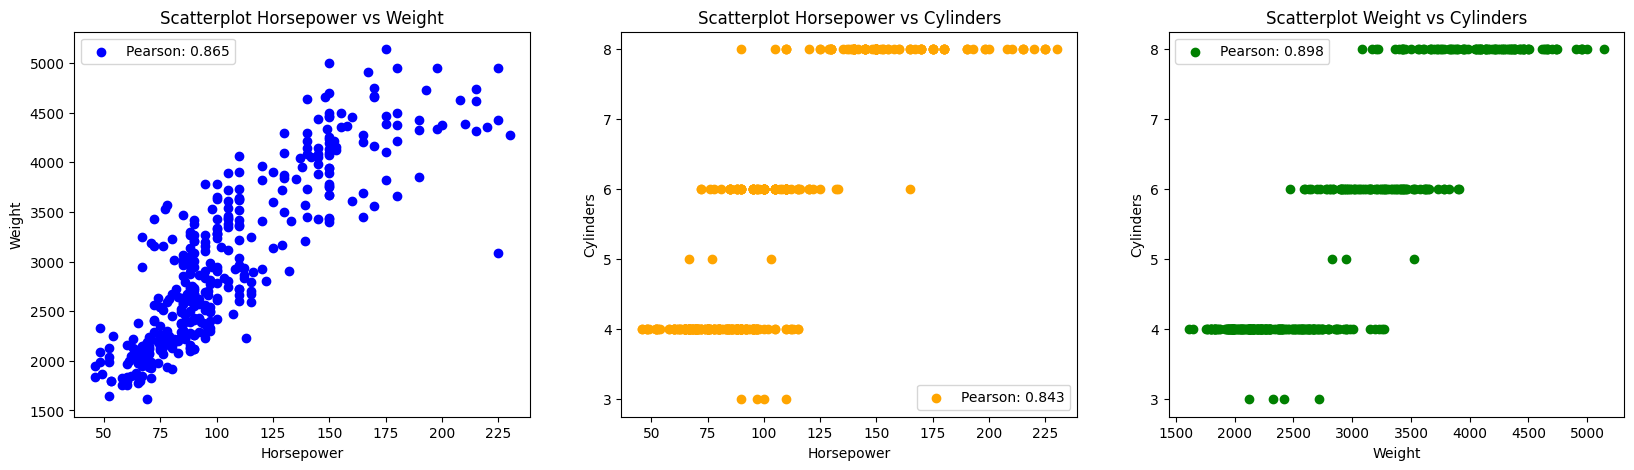

In [132]:
# Rutina de Graficación

fig, ax = plt.subplots(1, 3, figsize=(20,5), gridspec_kw = {'hspace':0.5})

ax[0].scatter(hp, weight, label = f'Pearson: {corr_hp_weight}', color = 'blue')
ax[0].set_title(f'Scatterplot Horsepower vs Weight')
ax[0].set_xlabel('Horsepower')
ax[0].set_ylabel('Weight')
ax[0].legend()

ax[1].scatter(hp,cylinders, label = f'Pearson: {corr_hp_cylinders}', color = 'orange')
ax[1].set_title(f'Scatterplot Horsepower vs Cylinders')
ax[1].set_xlabel('Horsepower')
ax[1].set_ylabel('Cylinders')
ax[1].legend()

ax[2].scatter(weight,cylinders, label = f'Pearson: {corr_weight_cylinders}', color = 'green')
ax[2].set_title(f'Scatterplot Weight vs Cylinders')
ax[2].set_xlabel('Weight')
ax[2].set_ylabel('Cylinders')
ax[2].legend()

plt.show()

# Análisis Inferencial

### Se busca analizar la relación que existe entre el peso de un auto y los caballos de fuerza que este posee.

In [133]:
# Análisis stats

from scipy import stats

### Se eliminan los valores "NaN" y se normalizan los datos para evitar disparidades considerables.

In [171]:
# Eliminación de valores NaN

df_car = df_car.dropna(subset=['weight','horsepower'])
weight = df_car['weight']
hp = df_car['horsepower']

In [172]:
# Normalización de datos

weight = (weight - weight.mean()) / weight.std()
hp = (hp - hp.mean()) / hp.std()

In [150]:
# Revisión de las dimensiones

print(len(hp),len(weight))

392 392


### Se aplica la prueba T para mostrar la relación entre los datos.

In [159]:
# Aplicamos prueba T de student

statistics, p_value = stats.ttest_ind(weight,hp)


print(f'Estadístico t: {statistics:.4f}')
print(f'p-value: {p_value:.4f}')

Estadístico t: 66.9017
p-value: 0.0000


In [160]:
# Interpretar resultados

if p_value < 0.01:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia muy significativa entre los datos de ambos grupos.")
elif p_value >= 0.01 and p_value < 0.05:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia altamente significativa entre los datos de ambos grupos.")
elif p_value >= 0.05 and p_value < 0.10:
    print("\nConclusión: Rechazamos la Hipótesis Nula.")
    print("Existe una diferencia moderadamente significativa entre los datos de ambos grupos.")
else:
    print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
    print("No hay evidencia suficiente para decir que los datos son diferentes.")


Conclusión: Rechazamos la Hipótesis Nula.
Existe una diferencia muy significativa entre los datos de ambos grupos.


### Ya teniendo esta información se procede a definir la regresión lineal para weight y horsepower

In [173]:
# Definir regresión lineal

linear_regression = np.polyfit(weight,hp,1)
beta, alpha = linear_regression

print(f'y = {beta} x + {alpha}')

y = 0.8645377375741431 x + -1.2336440746801092e-16


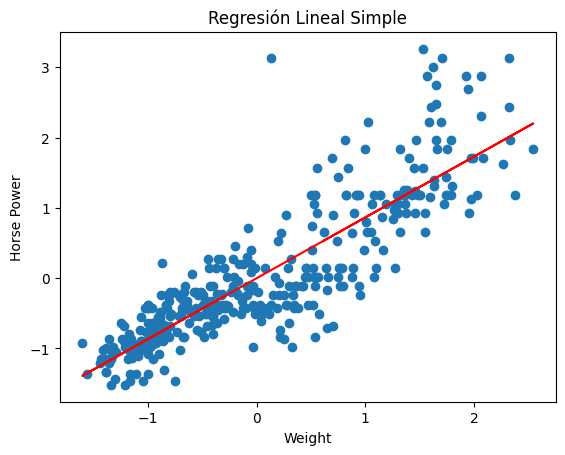

In [174]:
# Visualizar regresión lineal
plt.plot(weight, hp, 'o')
plt.plot(weight, beta * weight + alpha, 'r-')
plt.xlabel('Weight')
plt.ylabel('Horse Power')
plt.title('Regresión Lineal Simple')
plt.show()

Se usa gradiente descendiente también.

In [175]:
# Realizar algoritmo del descenso de gradiente

paso = 0.01
theta_0 = 0
theta_1 = 0

perdida = []


iteraciones = 1000

for i in range(iteraciones):
  y_pred = theta_1 * weight + theta_0
  #error = ((y_pred_lr - y_pred)**2).mean()
  #perdida.append(error)

  d_theta_0 = (2/len(weight)) * np.sum(y_pred - hp)
  d_theta_1 = (2/len(weight)) * np.sum((y_pred - hp) * weight)

  theta_0 = theta_0 - paso * d_theta_0
  theta_1 = theta_1 - paso * d_theta_1

print(f'y = {theta_1} x + {theta_0}')

y = 0.8645377360414008 x + -1.663975080172893e-16


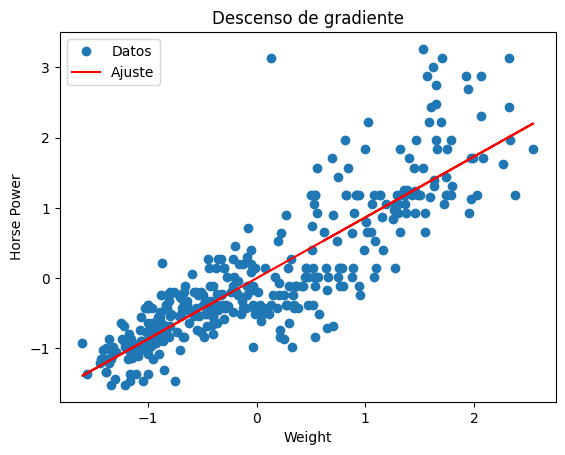

y = 0.8645377360414008 x + -1.663975080172893e-16


In [181]:
# Visualizar la regresión lineal por descenso de gradiente

plt.plot(weight, hp , 'o', label = 'Datos')
plt.plot(weight, theta_1 * weight + theta_0, 'r-', label = 'Ajuste')

plt.xlabel('Weight')
plt.ylabel('Horse Power')
plt.title('Descenso de gradiente')
plt.legend()
plt.show()
print(f'y = {theta_1} x + {theta_0}')

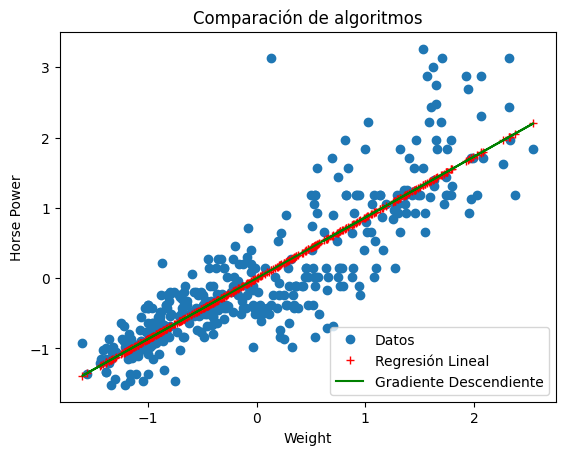

In [183]:
# Comparacion las rectas obtenidas por ambos algoritmos

plt.plot(weight, hp , 'o', label = 'Datos')
plt.plot(weight, beta * weight + alpha, 'r+', label = 'Regresión Lineal')
plt.plot(weight, theta_1 * weight + theta_0, 'g-', label = 'Gradiente Descendiente')

plt.xlabel('Weight')
plt.ylabel('Horse Power')
plt.title('Comparación de algoritmos')
plt.legend()